<a href="https://colab.research.google.com/github/Shubhanker01/ai-course/blob/main/SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[1 2 0 1 1 1 0 0 0 0 0 2 1 1 0 0 1 2 0 1 1 0 1 0 2 0 0 1 2 0]
0.8333333333333334
Train accuracy 0.7666666666666667
Test accuracy 0.8333333333333334


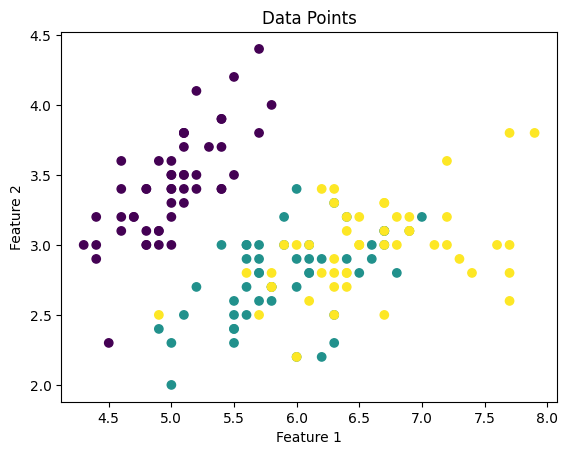

In [4]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from matplotlib import pyplot as plt
import numpy as np

# Load dataset
X,y = load_iris(return_X_y=True)
# removing 2 features
X = X[:,:2]
# split dataset
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2)

# preprocessing
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# create an SVM model
model = SVC(kernel='rbf')
# training the data
model.fit(X_train,y_train)

# prediction of data
y_pred = model.predict(X_test)
print(y_pred)
# evaluation
print(accuracy_score(y_test,y_pred))
# test for overfitting
print("Train accuracy",model.score(X_train,y_train))
print("Test accuracy",model.score(X_test,y_test))

# plotting points

# X = features, y = labels
plt.scatter(X[:, 0], X[:, 1], c=y)
# creating grid
xlim = plt.gca().get_xlim()
ylim = plt.gca().get_ylim()
xx = np.linspace(xlim[0], xlim[1],100)
yy = np.linspace(ylim[0], ylim[1],100)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()])
# xy = scaler.transform(xy.T)
# prediction over grid
Z = model.predict(xy.T)

Z = Z.reshape(XX.shape)

# plot boundary
plt.contour(XX,YY,Z,levels=[0.5])
plt.title("Decision Boundary")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Data Points")

plt.show()